In [1]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.constants import golden_ratio
from skimage.transform import radon
from skimage.transform.radon_transform import sart_projection_update
from skimage.restoration import denoise_tv_chambolle
from skimage.data import shepp_logan_phantom
from skimage import io
from matplotlib import pyplot as plt
from warnings import warn

/home/msmith693/dev/repos/tomography/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Modification of SART algorithm with added TV denoising
Taking SART algorithm iradon_sart() from scikit_image library and modifying it so that Total Variation denoising is applied in each step of the algroithm. This has been proven to produce better image reconstruction for sparse angle sets.

https://ieeexplore.ieee.org/document/6497957
 AND An Unsupervised Reconstruction Method For
Low-Dose CT Using Deep Generative
Regularization Prior LINK

# Unmodified helper function taken from scikit_image

Orders  projection angles so that less noise is produced when carrying out iterative algorithm. Sequential projections negatively affect the image reconstruction if used in sequential steps of the algorithm (from my understanding) so it is better to reorder the projection angles. There are multiple ways of doing this, one of which is through ordering with the golden ratio. Not vital to understanding of TV+SART algorithm, just refinement step. Taken directly from scikit_image library.


In [75]:
def order_angles_golden_ratio(theta):
    """Order angles to reduce the amount of correlated information in
    subsequent projections.

    Parameters
    ----------
    theta : array of floats, shape (M,)
        Projection angles in degrees. Duplicate angles are not allowed.

    Returns
    -------
    indices_generator : generator yielding unsigned integers
        The returned generator yields indices into ``theta`` such that
        ``theta[indices]`` gives the approximate golden ratio ordering
        of the projections. In total, ``len(theta)`` indices are yielded.
        All non-negative integers < ``len(theta)`` are yielded exactly once.

    Notes
    -----
    The method used here is that of the golden ratio introduced
    by T. Kohler.

    References
    ----------
    .. [1] Kohler, T. "A projection access scheme for iterative
           reconstruction based on the golden section." Nuclear Science
           Symposium Conference Record, 2004 IEEE. Vol. 6. IEEE, 2004.
    .. [2] Winkelmann, Stefanie, et al. "An optimal radial profile order
           based on the Golden Ratio for time-resolved MRI."
           Medical Imaging, IEEE Transactions on 26.1 (2007): 68-76.

    """
    interval = 180

    remaining_indices = list(np.argsort(theta))  # indices into theta
    # yield an arbitrary angle to start things off
    angle = theta[remaining_indices[0]]
    yield remaining_indices.pop(0)
    # determine subsequent angles using the golden ratio method
    angle_increment = interval / golden_ratio**2
    while remaining_indices:
        remaining_angles = theta[remaining_indices]
        angle = (angle + angle_increment) % interval
        index_above = np.searchsorted(remaining_angles, angle)
        index_below = index_above - 1
        index_above %= len(remaining_indices)

        diff_below = abs(angle - remaining_angles[index_below])
        distance_below = min(diff_below % interval, diff_below % -interval)

        diff_above = abs(angle - remaining_angles[index_above])
        distance_above = min(diff_above % interval, diff_above % -interval)

        if distance_below < distance_above:
            yield remaining_indices.pop(index_below)
        else:
            yield remaining_indices.pop(index_above)

# TV + SART


In [ ]:
# SART algorithm taken from scikit_image and modified to introduce TV denoising in iterative step.


def modified_sart_plus_tv(
    radon_image,
    theta=None,
    image=None,
    weight=0.1,
    projection_shifts=None,
    clip=None,
    relaxation=0.15,
    dtype=None,
):

    if radon_image.ndim != 2:
        raise ValueError("radon_image must be two dimensional")

    if dtype is None:
        if radon_image.dtype.char in "fd":
            dtype = radon_image.dtype
        else:
            warn(
                "Only floating point data type are valid for SART inverse "
                "radon transform. Input data is cast to float. To disable "
                "this warning, please cast image_radon to float."
            )
            dtype = np.dtype(float)
    elif np.dtype(dtype).char not in "fd":
        raise ValueError(
            "Only floating point data type are valid for inverse " "radon transform."
        )

    dtype = np.dtype(dtype)
    radon_image = radon_image.astype(dtype, copy=False)

    reconstructed_shape = (radon_image.shape[0], radon_image.shape[0])

    if theta is None:
        theta = np.linspace(0, 180, radon_image.shape[1], endpoint=False, dtype=dtype)
    elif len(theta) != radon_image.shape[1]:
        raise ValueError(
            f"Shape of theta ({len(theta)}) does not match the "
            f"number of projections ({radon_image.shape[1]})"
        )
    else:
        theta = np.asarray(theta, dtype=dtype)

    if image is None:
        image = np.zeros(reconstructed_shape, dtype=dtype)
    elif image.shape != reconstructed_shape:
        raise ValueError(
            f"Shape of image ({image.shape}) does not match first dimension "
            f"of radon_image ({reconstructed_shape})"
        )
    elif image.dtype != dtype:
        warn(f"image dtype does not match output dtype: " f"image is cast to {dtype}")

    image = np.asarray(image, dtype=dtype)

    if projection_shifts is None:
        projection_shifts = np.zeros((radon_image.shape[1],), dtype=dtype)
    elif len(projection_shifts) != radon_image.shape[1]:
        raise ValueError(
            f"Shape of projection_shifts ({len(projection_shifts)}) does not match the "
            f"number of projections ({radon_image.shape[1]})"
        )
    else:
        projection_shifts = np.asarray(projection_shifts, dtype=dtype)
    if clip is not None:
        if len(clip) != 2:
            raise ValueError("clip must be a length-2 sequence")
        clip = np.asarray(clip, dtype=dtype)

    # This is what matters. For each (reordered) angle, do:
    for angle_index in order_angles_golden_ratio(theta):
        image_update = sart_projection_update(
            image,
            theta[angle_index],
            radon_image[:, angle_index],
            projection_shifts[angle_index],
        )
        # TV applied on the image after each correction update.
        image += denoise_tv_chambolle((relaxation * image_update), weight=weight)
        if clip is not None:
            image = np.clip(image, clip[0], clip[1])
    return image

In [ ]:
# Helper function to generate number of angles (thetaval)
def generate_num_projections(int):
    return np.linspace(0, 180, int, endpoint=False)


def generate_sparse_sinogram(image, int):
    return radon(image, theta=generate_num_projections(int))

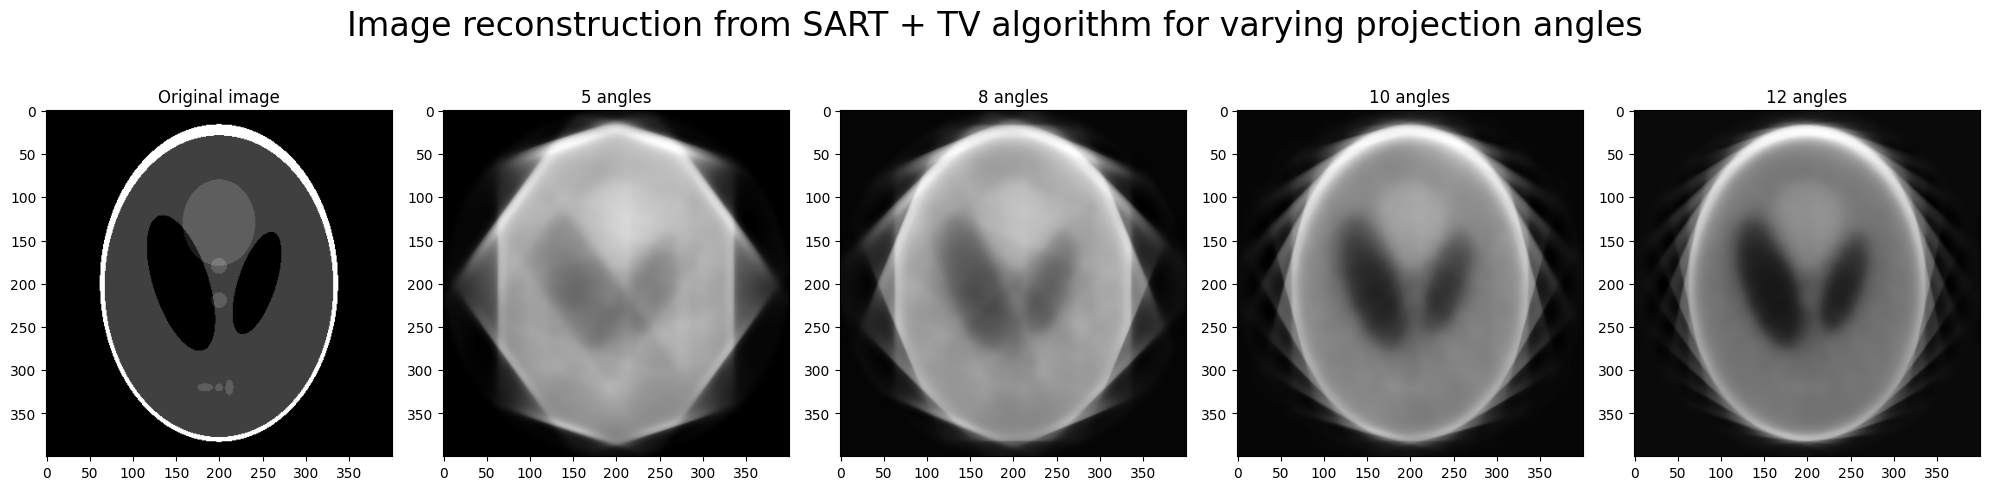

In [83]:
image = shepp_logan_phantom()
sinogram = radon(image)


reconstruction_image_5_angles = modified_sart_plus_tv(
    generate_sparse_sinogram(image, 5), theta=generate_num_projections(5)
)
reconstruction_image_8_angles = modified_sart_plus_tv(
    generate_sparse_sinogram(image, 8), theta=generate_num_projections(8)
)
reconstruction_image_12_angles = modified_sart_plus_tv(
    generate_sparse_sinogram(image, 12), theta=generate_num_projections(12)
)
reconstruction_image_15_angles = modified_sart_plus_tv(
    generate_sparse_sinogram(image, 15), theta=generate_num_projections(15)
)

imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 10))
fig.suptitle(
    "Image reconstruction from SART + TV algorithm for varying projection angles",
    y=0.75,
    fontsize=24,
)
ax1.set_title("Original image")
ax1.imshow(image, cmap=plt.cm.Greys_r)
ax2.set_title("5 angles")
ax2.imshow(reconstruction_image_5_angles, cmap=plt.cm.Greys_r)
ax3.set_title("8 angles")
ax3.imshow(reconstruction_image_8_angles, cmap=plt.cm.Greys_r)
ax4.set_title("10 angles")
ax4.imshow(reconstruction_image_12_angles, cmap=plt.cm.Greys_r)
ax5.set_title("12 angles")
ax5.imshow(reconstruction_image_15_angles, cmap=plt.cm.Greys_r)

fig.tight_layout()
plt.show()

# Testing noise functions

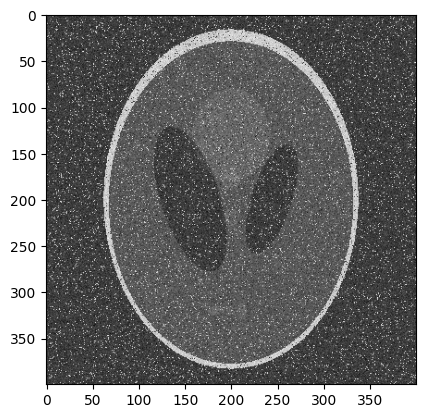

In [ ]:
image = shepp_logan_phantom()
# from skimage import io
# image = io.imread('images/cells.tif')[30,:,:]
def add_salt_pepper(image, prob):
    """
    Adds salt and pepper noise to image, with probability of pixel being affected equal to prob.
    Typical values for probability parameter are around 0.05.
    This changes random pixel value to 255 and 0 for salt and pepper noise repsectively.
    Leaves original image unmodified.
    """
    copy = image.copy()
    rand_array = np.random.rand(image.shape[0], image.shape[1])
    max_intensity = np.max(image)
    min_intensity = np.min(image)
   
    #set salt and pepper to max and min intensity vals of image as absolute maximum intensity vals (0, 1) look very unnatural
    copy[rand_array<prob] = min_intensity
    copy[rand_array>(1-prob)] = max_intensity

    return copy

def add_gaussian_noise(image, mu=0.0, sigma=0.1):
    """
    Adds Gaussian noise to image, with mu and sigma.

    Modifying mu will shift the noise to more high or low intensity noise.

    Modifying sigma affects amount of intensity variation in noise.
    """
    copy = image.copy()
    gaussian_noise_array = np.random.normal(
        mu, sigma, size=(image.shape[0], image.shape[1])
    )
    copy += gaussian_noise_array

    return copy

noise_image = add_salt_pepper(add_gaussian_noise(image), 0.05)
plt.imshow(noise_image, cmap='grey')



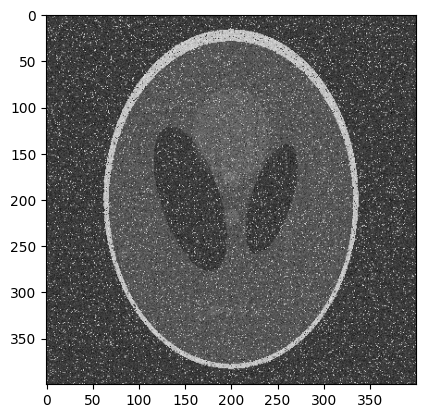

In [47]:
test_image = add_gaussian_noise(add_salt_pepper((image), 0.05))
plt.imshow(test_image, cmap='grey')